# Bayesian Nonparametric Survival Modeling (DPSM Extension)

This notebook introduces a model-based Bayesian nonparametric approach to survival estimation using a Dirichlet Process Survival Model (DPSM).

The goal is to assess how sensitive the estimated treatment effect $\Delta(t_0)$ is to the choice of survival model.

Previously, survival was estimated using:
- Kaplan–Meier estimators
- target-population weighting
- Dirichlet-based resampling for uncertainty

Here, we instead model the survival distribution directly using a nonparametric Bayesian model, and compare resulting estimates to the design-based pipeline.

This provides a complementary perspective on uncertainty and robustness.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.bnp.dpsm import fit_dpsm, compute_delta_posterior

DATA_DIR = Path("../data/processed")

# Main real-data pipeline inputs
df_kmgpt = pd.read_csv(DATA_DIR / "real_kmgpt_ipd_with_covariates.csv")

# Existing pipeline results for comparison
weighted_kmgpt = pd.read_csv("../data/interim/weighted_estimate.csv")
bnp_kmgpt = pd.read_csv("../data/interim/bnp_summary.csv")
naive_kmgpt = pd.read_csv(DATA_DIR / "naive_pooled_effect.csv")

print("Loaded KM-GPT data:", df_kmgpt.shape)
df_kmgpt.head()

Loaded KM-GPT data: (776, 18)


,trial_id,subgroup,time,event,arm_label,curve,treatment,age_median,male_rate,ecog0_rate,metastatic_rate,biomarker_rate,age,male,ecog0,metastatic,biomarker,stage
0,KEYNOTE-181,high_pdl1,0.731707,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,56.369120,1,0,0,0,1.165542
1,KEYNOTE-181,high_pdl1,0.890244,0,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,68.148584,1,1,1,0,1.822921
2,KEYNOTE-181,high_pdl1,1.048780,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,58.035384,1,0,1,1,2.330231
3,KEYNOTE-181,high_pdl1,1.243902,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,61.334523,1,1,1,1,1.968789
4,KEYNOTE-181,high_pdl1,1.365854,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,73.194077,1,0,1,1,2.342307


## DPSM Setup

We fit a treatment-specific Bayesian nonparametric survival model using a Dirichlet-process-style mixture of exponential kernels.

This provides a model-based alternative to the empirical Kaplan–Meier + weighting pipeline. The goal is not to replace the main pipeline, but to assess whether the estimated treatment effect at a fixed time horizon is sensitive to the choice of survival model.

In [3]:
# DPSM Fit
dpsm_fit = fit_dpsm(
    df=df_kmgpt,
    time_col="time",
    event_col="event",
    treatment_col="treatment",
    n_components=8,
    alpha=1.0,
    rate_shape=1.0,
    rate_scale=1.0,
    n_samples=400,
    burn_in=400,
    thin=2,
    random_state=733,
    t0_default=12.0,
)

dpsm_fit.metadata

{'n_components': 8,
 'alpha': 1.0,
 'rate_shape': 1.0,
 'rate_scale': 1.0,
 'n_samples': 400,
 'burn_in': 400,
 'thin': 2,
 'random_state': 733,
 'time_col': 'time',
 'event_col': 'event',
 'treatment_col': 'treatment',
 'n_obs': 776,
 'n_treat0': 388,
 'n_treat1': 388}

In [4]:
# Posterior Summary
dpsm_results = compute_delta_posterior(
    dpsm_fit,
    t0=12.0,
)

dpsm_summary = pd.DataFrame([{
    "t0": dpsm_results["t0"],
    "S0_mean": dpsm_results["S0_mean"],
    "S1_mean": dpsm_results["S1_mean"],
    "Delta_mean": dpsm_results["mean"],
    "Delta_sd": dpsm_results["sd"],
    "Delta_q025": dpsm_results["q025"],
    "Delta_q975": dpsm_results["q975"],
}])

dpsm_summary.round(3)

,t0,S0_mean,S1_mean,Delta_mean,Delta_sd,Delta_q025,Delta_q975
0,12.0,0.329,0.449,0.12,0.028,0.064,0.168


In [5]:
# Comparison to KMGPT pipeline
comparison = pd.DataFrame({
    "method": ["Naive KM", "Weighted KM", "BNP Bootstrap", "DPSM"],
    "Delta_mean": [
        naive_kmgpt["Delta"].iloc[0],
        weighted_kmgpt["Delta"].iloc[0],
        bnp_kmgpt["mean"].iloc[0],
        dpsm_results["mean"],
    ],
    "q025": [
        np.nan,
        np.nan,
        bnp_kmgpt["q025"].iloc[0],
        dpsm_results["q025"],
    ],
    "q975": [
        np.nan,
        np.nan,
        bnp_kmgpt["q975"].iloc[0],
        dpsm_results["q975"],
    ],
})

comparison.round(3)

,method,Delta_mean,q025,q975
0,Naive KM,0.169,NaN,NaN
1,Weighted KM,0.234,NaN,NaN
2,BNP Bootstrap,0.205,0.052,0.361
3,DPSM,0.120,0.064,0.168


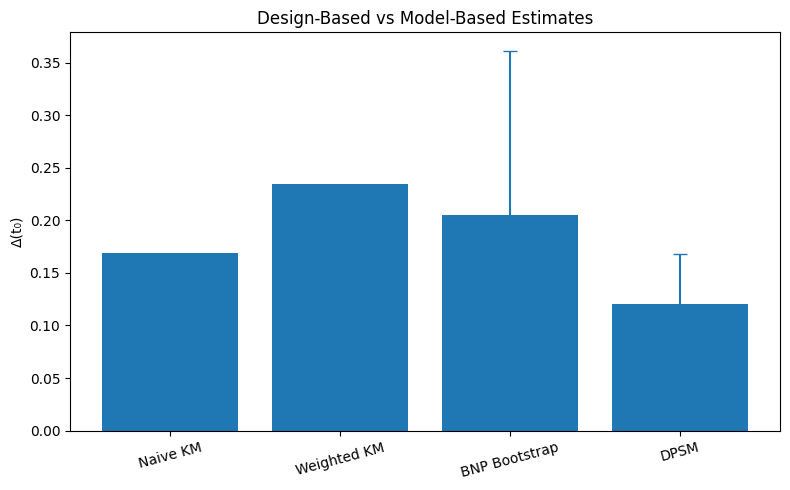

In [6]:
# Model vs Design
methods = comparison["method"].tolist()
means = comparison["Delta_mean"].to_numpy()
lower = comparison["q025"].to_numpy()
upper = comparison["q975"].to_numpy()

x = np.arange(len(methods))

plt.figure(figsize=(8, 5))
plt.bar(x, means)

mask = ~np.isnan(lower)
plt.errorbar(
    x[mask],
    means[mask],
    yerr=[
        means[mask] - lower[mask],
        upper[mask] - means[mask],
    ],
    fmt="none",
    capsize=5,
)

plt.xticks(x, methods, rotation=15)
plt.ylabel("Δ(t₀)")
plt.title("Design-Based vs Model-Based Estimates")
plt.tight_layout()
plt.show()

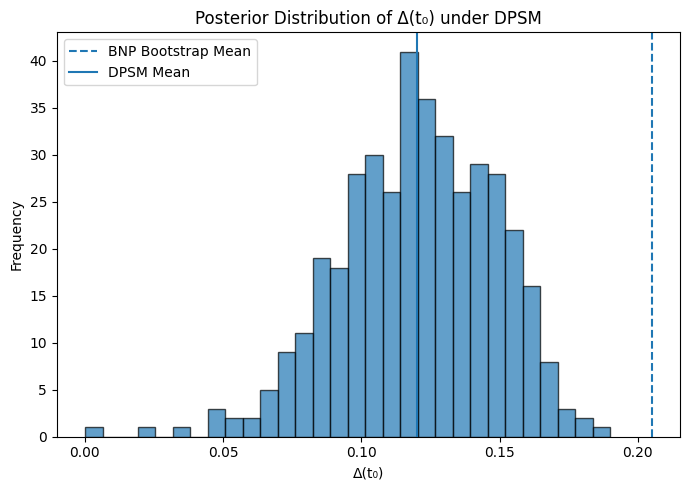

In [7]:
# Posterior Draws
plt.figure(figsize=(7, 5))
plt.hist(dpsm_results["delta_draws"], bins=30, edgecolor="black", alpha=0.7)
plt.axvline(bnp_kmgpt["mean"].iloc[0], linestyle="--", label="BNP Bootstrap Mean")
plt.axvline(dpsm_results["mean"], linestyle="-", label="DPSM Mean")
plt.xlabel("Δ(t₀)")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Δ(t₀) under DPSM")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# pickling
dpsm_summary.to_csv(DATA_DIR / "dpsm_summary.csv", index=False)

pd.DataFrame({
    "delta": dpsm_results["delta_draws"],
    "s0": dpsm_results["s0_draws"],
    "s1": dpsm_results["s1_draws"],
}).to_csv(DATA_DIR / "dpsm_draws.csv", index=False)

comparison.to_csv(DATA_DIR / "dpsm_comparison.csv", index=False)

print("Saved DPSM outputs.")

Saved DPSM outputs.
